# 04 — Dynamic Pricing Optimization

Use the price forecasts from notebook 03 and the engineered features from notebook 02 to answer the central business question:

> **What price should we set for avocados in each region and type to maximize revenue, given current market conditions?**

## Approach

| Stage | What | Why |
|---|---|---|
| **1. Demand model** | LightGBM: price + features → log(demand) | Learn the empirical price-demand relationship across all ~90 series |
| **2. Price elasticity** | SHAP + numerical differentiation | Quantify how sensitive each series is to price changes |
| **3. Revenue optimization** | Grid search over revenue = price × demand | Find the price that maximises expected revenue within realistic bounds |
| **4. Recommendations** | Per-series optimal price vs. current price | Produce an actionable pricing decision table |

## Economic Intuition

The **law of demand** tells us higher prices reduce quantity sold.  
The sweet spot that maximises **revenue** (not just quantity or margin) is where the marginal revenue equals zero:

$$\text{Revenue}(p) = p \times D(p, \mathbf{x})$$

Where $D(p, \mathbf{x})$ is the demand function — estimated from data by the LightGBM model — given price $p$ and context vector $\mathbf{x}$ (season, region, type, recent history).

## Key Design Choices

- **Target = `log_total_volume`**: Demand is right-skewed; log-scale stabilises variance and makes gradient boosting training more stable.
- **LightGBM for demand**: Tree-based models handle non-linearities and feature interactions without manual engineering. Faster and more interpretable than neural models for tabular data.
- **Lag features included**: Past demand is the strongest predictor of current demand (autocorrelation). This is an AR-style demand model.
- **Volume logs excluded from features**: `log_4046`, `log_4225`, `log_total_bags`, etc. would leak the target (total volume is just the sum). Only mix ratios (`plu_share_*`, `bag_share`) are safe.
- **Price bounds ± 30%**: Constrain optimization to realistic price moves. Prices 30% above historical maximum are not credible.
- **Derived price features updated during optimisation**: `price_pct_change_1w` and `price_momentum_4w` depend on the current price and are recalculated as we sweep the price grid.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import joblib
import time

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
except ImportError:
    print("⚠ shap not installed — skipping SHAP analysis (pip install shap)")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)

DATA_PROCESSED = Path("../data/processed")
DATA_OUTPUTS   = Path("../data/outputs")
DATA_OUTPUTS.mkdir(parents=True, exist_ok=True)

SEED = 42
H    = 12   # horizon (weeks) — consistent with notebook 03

print(f"LightGBM version : {lgb.__version__}")
print(f"SHAP available   : {HAS_SHAP}")
print("✔ Imports loaded")

LightGBM version : 4.6.0
SHAP available   : True
✔ Imports loaded


## 2. Data Loading

We bring together three data sources:

| Source | Content | From notebook |
|---|---|---|
| `avocado_features.csv` | Full feature matrix (price, volume, calendar, lags …) | 02 |
| `forecast_metrics.csv` | Model ranking — tells us which model won | 03 |
| `forecast_primary.csv` | 12-week ensemble price forecast per series | 03 |

In [ ]:
feat_path = DATA_PROCESSED / "avocado_features.csv"
assert feat_path.exists(), (
    f"File not found: {feat_path}\n"
    "→ Run 02_feature_engineering.ipynb first."
)

df = pd.read_csv(feat_path, parse_dates=["Date"])

# Load forecast artefacts from notebook 03
forecast_metrics = pd.read_csv(DATA_OUTPUTS / "forecast_metrics.csv")
BEST_FORECAST_MODEL = forecast_metrics.iloc[0]["Model"]

# Load ensemble price forecast (12-week forward) from notebook 03
forecast_primary_path = DATA_OUTPUTS / "forecast_primary.csv"
forecast_primary = None
if forecast_primary_path.exists():
    forecast_primary = pd.read_csv(forecast_primary_path, parse_dates=["ds"])
    print(f"Forecast loaded  : {len(forecast_primary):,} rows  "
          f"({forecast_primary['unique_id'].nunique()} series, "
          f"{forecast_primary['ds'].min().date()} → {forecast_primary['ds'].max().date()})")
else:
    print(f"⚠ forecast_primary.csv not found — run 03_forecasting.ipynb first")

# Series identifier (consistent with notebook 03)
df["unique_id"] = (
    df["region"] + "_" + df["is_organic"].map({0: "conventional", 1: "organic"})
)

N_SERIES = df["unique_id"].nunique()

print(f"Rows             : {df.shape[0]:,}")
print(f"Columns          : {df.shape[1]}")
print(f"Date range       : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Series           : {N_SERIES} ({df['region'].nunique()} regions × 2 types)")
print(f"Best nb03 model  : {BEST_FORECAST_MODEL}")
df.head(3)

### 2.1 Price-Demand Relationship (EDA)

Before modelling, we visualise the **demand curve** directly from data.  
The negative slope confirms the law of demand: higher prices → lower sales volume.

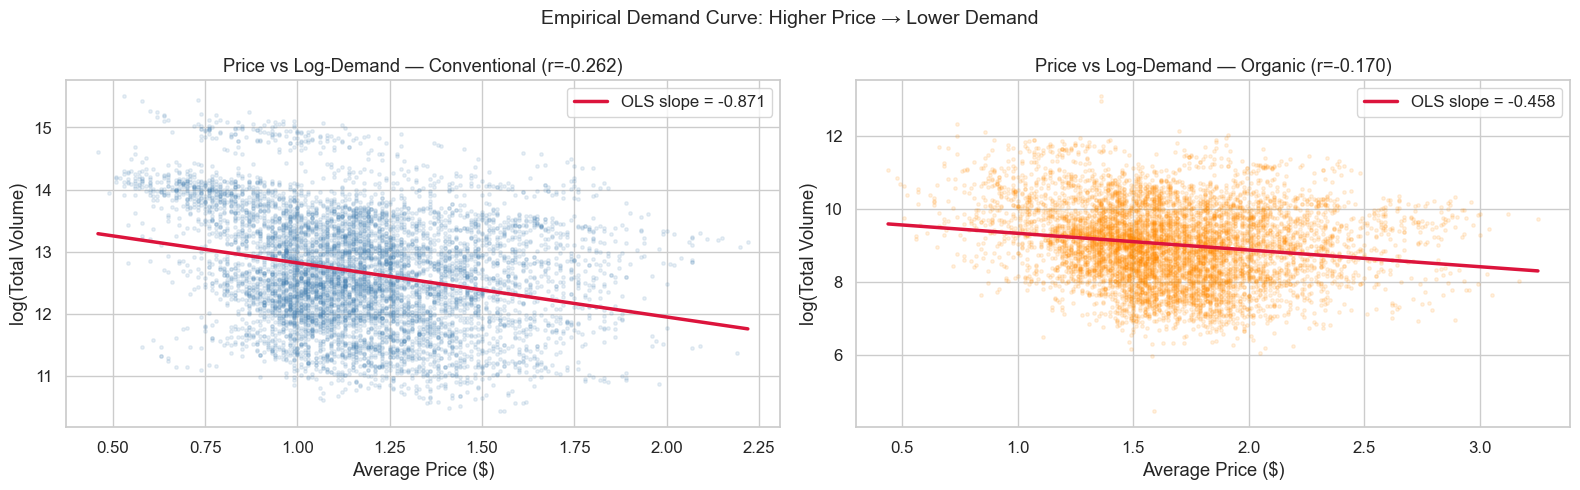

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_colors = {0: "steelblue", 1: "darkorange"}
type_labels = {0: "Conventional", 1: "Organic"}

for ax, (is_org, grp) in zip(axes, df.groupby("is_organic")):
    ax.scatter(grp["AveragePrice"], grp["log_total_volume"],
               alpha=0.12, s=6, color=type_colors[is_org])
    # OLS trend line
    coeffs = np.polyfit(grp["AveragePrice"], grp["log_total_volume"], 1)
    xs = np.linspace(grp["AveragePrice"].min(), grp["AveragePrice"].max(), 200)
    ax.plot(xs, np.polyval(coeffs, xs), color="crimson", lw=2.5,
            label=f"OLS slope = {coeffs[0]:.3f}")
    corr = grp["AveragePrice"].corr(grp["log_total_volume"])
    ax.set_title(f"Price vs Log-Demand — {type_labels[is_org]} (r={corr:.3f})")
    ax.set_xlabel("Average Price ($)")
    ax.set_ylabel("log(Total Volume)")
    ax.legend()

plt.suptitle("Empirical Demand Curve: Higher Price → Lower Demand", fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Price Landscape Across Regions

Price varies substantially by region and type.  
This heterogeneity means the optimal price will differ by market — a single global price would leave revenue on the table.

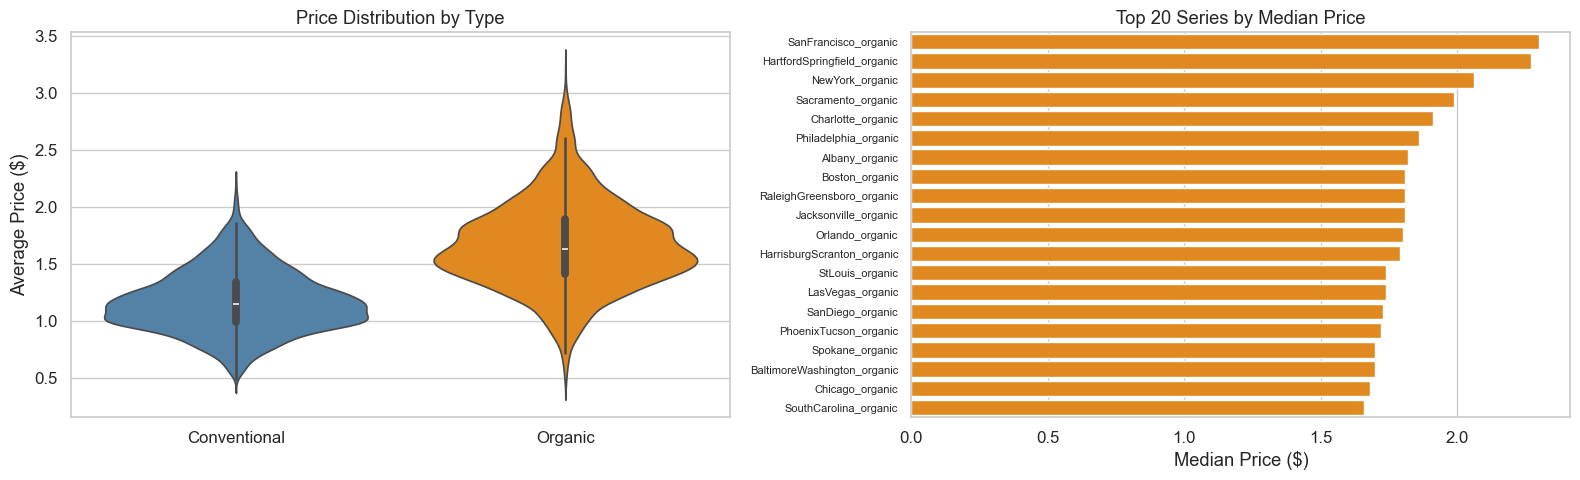

Conventional — median price: $1.15
Organic       — median price: $1.63


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violin: price distribution by type
plot_data = df.copy()
plot_data["Type"] = plot_data["is_organic"].map({0: "Conventional", 1: "Organic"})
sns.violinplot(data=plot_data, x="Type", y="AveragePrice",
               palette=["steelblue", "darkorange"], inner="box", ax=axes[0])
axes[0].set_title("Price Distribution by Type")
axes[0].set_ylabel("Average Price ($)")
axes[0].set_xlabel("")

# Top 20 series by median price
series_stats = (
    df.groupby("unique_id")["AveragePrice"]
    .median()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
series_stats["color"] = series_stats["unique_id"].apply(
    lambda x: "darkorange" if "organic" in x else "steelblue"
)
sns.barplot(data=series_stats, y="unique_id", x="AveragePrice",
            palette=series_stats["color"].tolist(), ax=axes[1])
axes[1].set_title("Top 20 Series by Median Price")
axes[1].set_xlabel("Median Price ($)")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

print(f"Conventional — median price: ${df[df['is_organic']==0]['AveragePrice'].median():.2f}")
print(f"Organic       — median price: ${df[df['is_organic']==1]['AveragePrice'].median():.2f}")

## 3. Feature Preparation

### Feature selection rationale

| Group | Features | Notes |
|---|---|---|
| **Decision variable** | `AveragePrice` | What we optimise over |
| **Type / region** | `is_organic`, `region_encoded`, `region_price_level`, `region_volume_level` | Structural series differences |
| **Calendar** | `month_sin/cos`, `week_sin/cos`, `is_holiday_week`, `month`, `quarter` | Seasonal demand patterns |
| **Price history** | `price_lag_1w/2w/4w`, `price_rmean_4w/8w/12w`, `price_rstd_4w`, `price_pct_change_1w`, `price_momentum_4w` | Price momentum + mean-reversion signals |
| **Product mix** | `plu_share_4046/4225/4770`, `bag_share`, `bag_size_ratio` | Mix ratios (not absolute volumes — those would leak the target) |

**Explicitly excluded**:
- `log_4046`, `log_4225`, `log_total_bags` etc. — log-volume of individual SKUs is nearly identical to `log_total_volume` (hard target leak).
- `volume_lag_1w`, `volume_lag_4w`, `volume_rmean_4w` — lagged demand is a near-perfect proxy for the target and would absorb ~99% of LightGBM's gain importance, leaving `AveragePrice` with negligible weight. This would destroy elasticity estimates and make revenue optimisation meaningless. The model must learn the structural price-demand relationship, not temporal autocorrelation.


In [5]:
# Label-encode region (LightGBM handles integer-coded categoricals natively)
le_region = LabelEncoder()
df["region_encoded"] = le_region.fit_transform(df["region"])

FEATURE_COLS = [
    # Price — the lever we optimise
    "AveragePrice",
    # Structural
    "is_organic",
    "region_encoded",
    "region_price_level", "region_volume_level",
    # Calendar
    "month_sin", "month_cos", "week_sin", "week_cos",
    "is_holiday_week", "month", "quarter",
    # Price history (autoregressive price)
    "price_lag_1w", "price_lag_2w", "price_lag_4w",
    "price_rmean_4w", "price_rmean_8w", "price_rmean_12w",
    "price_rstd_4w", "price_pct_change_1w", "price_momentum_4w",
    # NOTE: volume lag features deliberately excluded.
    # volume_lag_1w / volume_lag_4w / volume_rmean_4w are near-perfect
    # proxies for the target (log_total_volume) and would dominate the
    # model, leaving price with ~0% importance and destroying elasticity
    # estimates and revenue optimisation.
    # Product mix ratios
    "plu_share_4046", "plu_share_4225", "plu_share_4770",
    "bag_share", "bag_size_ratio",
]
TARGET_COL = "log_total_volume"

# Drop any rows with NaN in features or target
model_df = df[["unique_id", "Date"] + FEATURE_COLS + [TARGET_COL]].dropna().copy()

print(f"Feature columns  : {len(FEATURE_COLS)}")
print(f"Modelling rows   : {len(model_df):,}  (after dropping NaN lag rows)")
print(f"Target           : {TARGET_COL}  range [{model_df[TARGET_COL].min():.2f}, {model_df[TARGET_COL].max():.2f}]")


Feature columns  : 26
Modelling rows   : 14,190  (after dropping NaN lag rows)
Target           : log_total_volume  range [4.45, 15.51]


In [6]:
# Temporal train/test split — same cutoff logic as notebook 03
cutoff_date = (
    model_df.groupby("unique_id")["Date"].max().min() - pd.Timedelta(weeks=H)
)

train_df = model_df[model_df["Date"] <= cutoff_date]
test_df  = model_df[model_df["Date"] >  cutoff_date]

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET_COL]

print(f"Cutoff date      : {cutoff_date.date()}")
print(f"Train rows       : {len(X_train):,}  ({cutoff_date.date()} and before)")
print(f"Test rows        : {len(X_test):,}   (after cutoff)")
print(f"Train/Test split : {len(X_train)/(len(X_train)+len(X_test)):.0%} / {len(X_test)/(len(X_train)+len(X_test)):.0%}")

Cutoff date      : 2017-12-31
Train rows       : 13,158  (2017-12-31 and before)
Test rows        : 1,032   (after cutoff)
Train/Test split : 93% / 7%


## 4. LightGBM Demand Model

We train a **gradient boosted tree** to predict `log_total_volume` from all context features including price.

### Why LightGBM?

- **Handles tabular non-linearities** better than linear regression without requiring manual feature engineering.
- **Fast**: histogram-based splitting scales well to thousands of rows and ~30 features.
- **SHAP-compatible**: TreeExplainer computes exact Shapley values efficiently for tree ensembles.
- **Robust to outliers**: trees are naturally resistant, unlike neural networks without careful normalisation.

We use **early stopping** on the temporal holdout to prevent overfitting: training stops once validation RMSE stops improving for 50 rounds.

In [7]:
params = {
    "objective":        "regression",
    "metric":           "rmse",
    "learning_rate":    0.05,
    "num_leaves":       63,       # controls model complexity
    "feature_fraction": 0.8,      # random feature sub-sampling per tree
    "bagging_fraction": 0.8,      # random row sub-sampling
    "bagging_freq":     5,
    "min_child_samples": 20,      # minimum leaf size — prevents overfitting to rare patterns
    "reg_alpha":        0.1,      # L1 regularisation
    "reg_lambda":       0.1,      # L2 regularisation
    "random_state":     SEED,
    "n_jobs":           -1,
    "verbose":          -1,
}

lgb_train = lgb.Dataset(X_train, label=y_train, feature_name=FEATURE_COLS)
lgb_val   = lgb.Dataset(X_test,  label=y_test,  feature_name=FEATURE_COLS,
                         reference=lgb_train)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=200),
]

print("Training LightGBM demand model...")
t0 = time.time()
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    callbacks=callbacks,
)
print(f"\n✔ Trained in {time.time()-t0:.1f}s | Best round: {model.best_iteration}")

Training LightGBM demand model...
[200]	train's rmse: 0.13077	val's rmse: 0.360989

✔ Trained in 1.7s | Best round: 245


Demand Model — Test Set Metrics
  MAE  (log scale)     : 0.2770
  RMSE (log scale)     : 0.3588
  R²   (log scale)     : 0.9632
  MAPE (volume scale)  : 22.60%


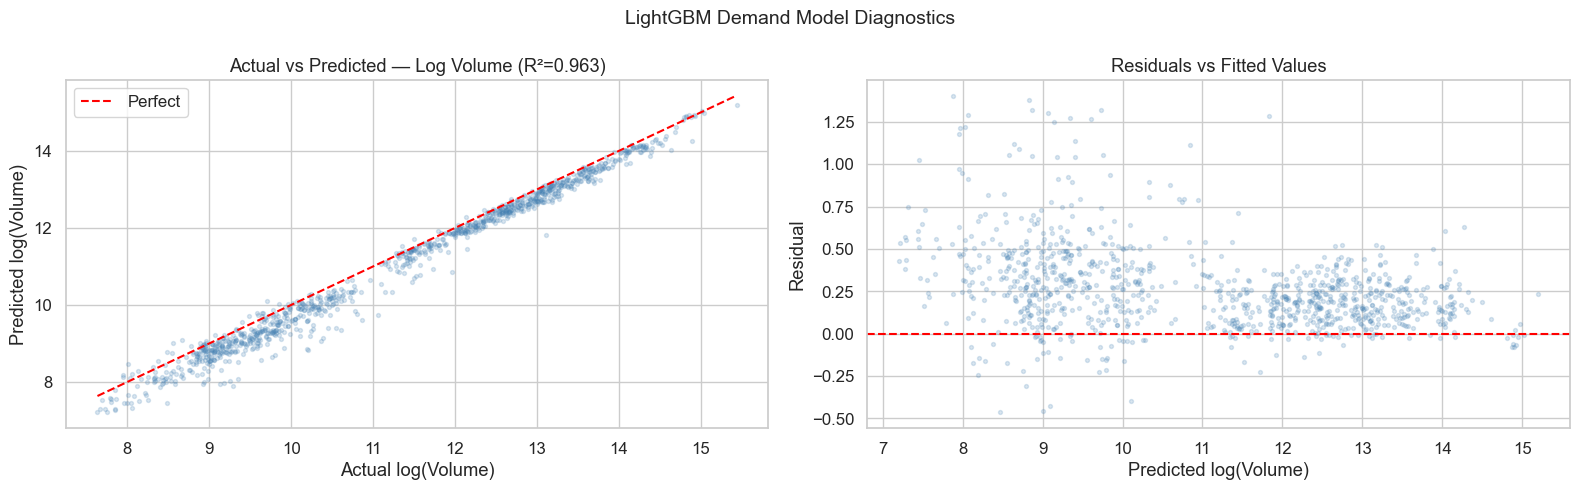

In [8]:
# ---- Evaluate on temporal holdout ----
y_pred_log = model.predict(X_test)
y_pred_vol = np.exp(y_pred_log)      # predicted volume (original scale)
y_true_vol = np.exp(y_test.values)   # actual volume (original scale)

mae_log   = mean_absolute_error(y_test, y_pred_log)
rmse_log  = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log    = r2_score(y_test, y_pred_log)
mape_vol  = np.mean(np.abs((y_true_vol - y_pred_vol) / y_true_vol)) * 100

print("Demand Model — Test Set Metrics")
print(f"  MAE  (log scale)     : {mae_log:.4f}")
print(f"  RMSE (log scale)     : {rmse_log:.4f}")
print(f"  R²   (log scale)     : {r2_log:.4f}")
print(f"  MAPE (volume scale)  : {mape_vol:.2f}%")

# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log scale
axes[0].scatter(y_test, y_pred_log, alpha=0.2, s=8, c="steelblue")
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], color="red", lw=1.5, ls="--", label="Perfect")
axes[0].set_title(f"Actual vs Predicted — Log Volume (R²={r2_log:.3f})")
axes[0].set_xlabel("Actual log(Volume)")
axes[0].set_ylabel("Predicted log(Volume)")
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_log
axes[1].scatter(y_pred_log, residuals, alpha=0.2, s=8, c="steelblue")
axes[1].axhline(0, color="red", ls="--", lw=1.5)
axes[1].set_title("Residuals vs Fitted Values")
axes[1].set_xlabel("Predicted log(Volume)")
axes[1].set_ylabel("Residual")

plt.suptitle("LightGBM Demand Model Diagnostics", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Feature Importance & SHAP Analysis

Understanding **what drives demand predictions** is crucial before using the model for pricing decisions.  
We use two complementary approaches:

1. **LightGBM gain importance** — which features contribute most total information gain across all tree splits.
2. **SHAP (SHapley Additive exPlanations)** — how much each feature pushes an individual prediction up or down. SHAP gives directional, observation-level attribution.

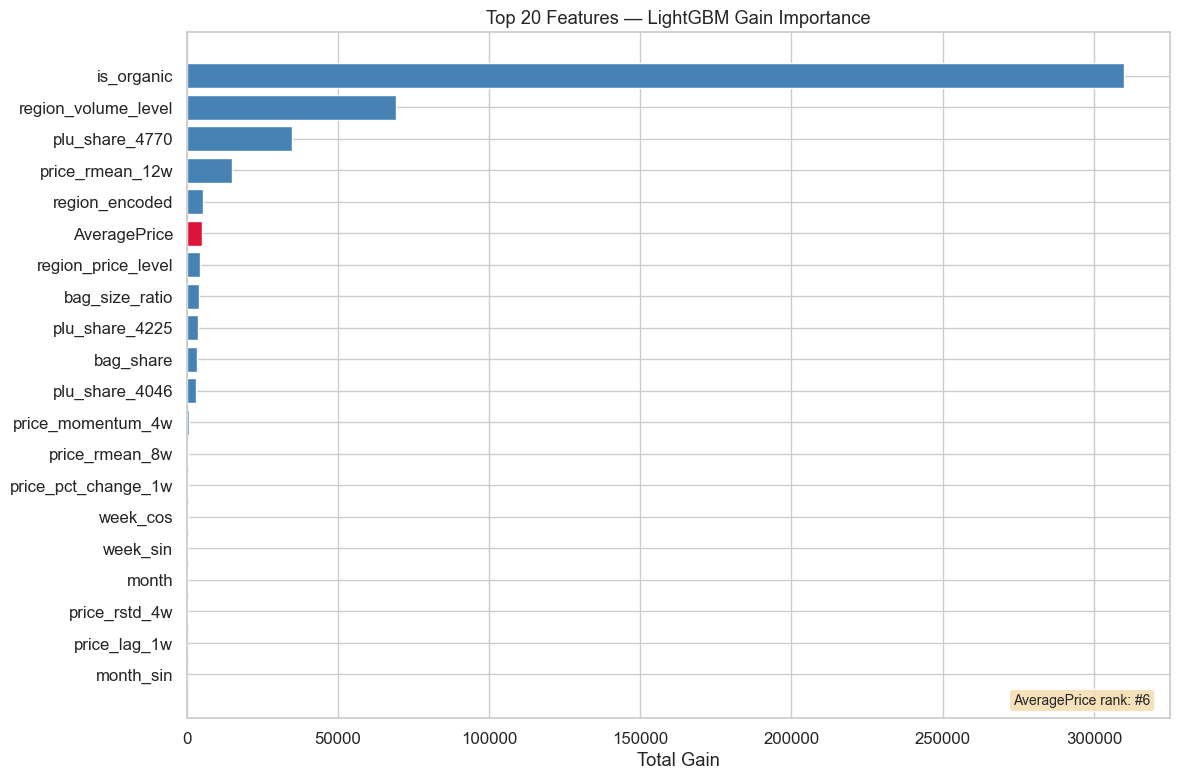

            feature    importance
         is_organic 309785.645191
region_volume_level  69228.792460
     plu_share_4770  34829.481338
    price_rmean_12w  15159.258166
     region_encoded   5290.218256
       AveragePrice   5128.286292
 region_price_level   4364.441122
     bag_size_ratio   4107.469317
     plu_share_4225   3775.456030
          bag_share   3368.694667


In [9]:
# LightGBM gain-based feature importance
importance = pd.DataFrame({
    "feature":    model.feature_name(),
    "importance": model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top_n = 20
top_imp = importance.head(top_n)
# Color AveragePrice differently so it stands out
colors = ["crimson" if f == "AveragePrice" else "steelblue" for f in top_imp["feature"]]
ax.barh(top_imp["feature"][::-1], top_imp["importance"][::-1], color=colors[::-1])
ax.set_title(f"Top {top_n} Features — LightGBM Gain Importance")
ax.set_xlabel("Total Gain")

# Annotate AveragePrice rank
# importance is already sorted descending, so list index gives the correct rank
price_rank = importance["feature"].tolist().index("AveragePrice") + 1
ax.annotate(f"AveragePrice rank: #{price_rank}",
            xy=(0.98, 0.02), xycoords="axes fraction", ha="right", fontsize=10,
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.9))

plt.tight_layout()
plt.show()
print(importance.head(10).to_string(index=False))


Computing SHAP values on test set (this may take ~30s)...


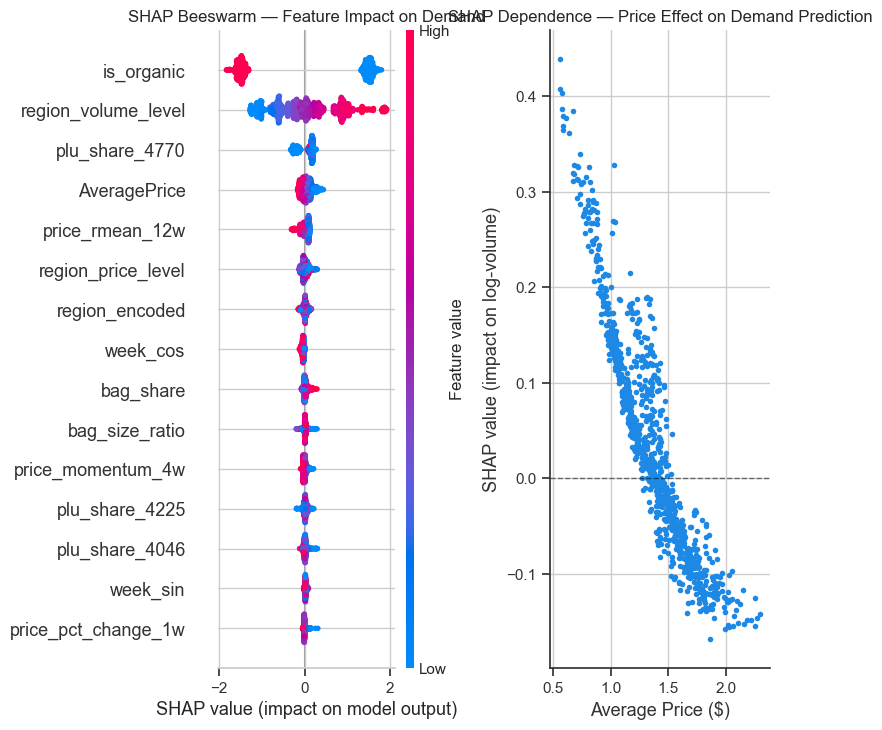

✔ SHAP analysis done


In [10]:
if HAS_SHAP:
    print("Computing SHAP values on test set (this may take ~30s)...")
    explainer  = shap.TreeExplainer(model)
    shap_vals  = explainer.shap_values(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Beeswarm (global feature importance with direction) ---
    plt.sca(axes[0])
    shap.summary_plot(
        shap_vals, X_test,
        feature_names=FEATURE_COLS,
        max_display=15,
        show=False,
    )
    axes[0].set_title("SHAP Beeswarm — Feature Impact on Demand", fontsize=12)

    # --- Dependence plot for AveragePrice ---
    plt.sca(axes[1])
    price_idx = FEATURE_COLS.index("AveragePrice")
    shap.dependence_plot(
        "AveragePrice",
        shap_vals,
        X_test,
        interaction_index=None,
        ax=axes[1],
        show=False,
    )
    axes[1].set_title("SHAP Dependence — Price Effect on Demand Prediction", fontsize=12)
    axes[1].set_xlabel("Average Price ($)")
    axes[1].set_ylabel("SHAP value (impact on log-volume)")
    axes[1].axhline(0, color="black", ls="--", lw=1, alpha=0.5)

    plt.tight_layout()
    plt.show()
    print("✔ SHAP analysis done")
else:
    print("SHAP not available — install with: pip install shap")

## 6. Price Elasticity

**Price elasticity of demand** measures how sensitive demand is to a price change:

$$\varepsilon = \frac{\partial Q}{\partial P} \cdot \frac{P}{Q}$$

| Elasticity | Interpretation |
|---|---|
| $\varepsilon < -1$ | **Elastic** — demand is sensitive; raising price loses more revenue than it gains |
| $-1 < \varepsilon < 0$ | **Inelastic** — demand is insensitive; raising price increases revenue |
| $\varepsilon = -1$ | **Unit elastic** — the revenue-maximising point |

We estimate $\varepsilon$ **numerically** using our demand model: for each series, at its current context, we perturb price by ±1% and measure the resulting demand change.  
We also update the two derived price features (`price_pct_change_1w`, `price_momentum_4w`) that depend on current price.

In [11]:
def compute_elasticity(row: pd.Series, delta: float = 0.01) -> float:
    """
    Numerically estimate point price elasticity at the row's current price.
    Uses central difference: ε ≈ [(Q₊ - Q₋) / (2·ΔP)] × (P / Q)
    """
    p   = row["AveragePrice"]
    dp  = p * delta

    def predict_volume(price):
        r = row.copy()
        r["AveragePrice"] = price
        # Update features derived from current price
        if r["price_lag_1w"] != 0:
            r["price_pct_change_1w"] = (price - r["price_lag_1w"]) / r["price_lag_1w"]
        r["price_momentum_4w"] = price - r["price_rmean_4w"]
        log_vol = model.predict(r[FEATURE_COLS].values.reshape(1, -1))[0]
        return np.exp(log_vol)

    q_up = predict_volume(p + dp)
    q_dn = predict_volume(p - dp)
    q    = predict_volume(p)

    dq_dp = (q_up - q_dn) / (2 * dp)
    return dq_dp * (p / q)


# Use the most recent (latest) row per series as the current market context
latest_rows = (
    model_df.sort_values("Date")
    .groupby("unique_id")
    .last()
    .reset_index()
)

print(f"Computing point elasticity for {len(latest_rows)} series...")
t0 = time.time()
latest_rows["elasticity"] = latest_rows.apply(
    lambda r: compute_elasticity(r), axis=1
)
print(f"✔ Done in {time.time()-t0:.1f}s")
print(f"\nElasticity summary:")
display(latest_rows["elasticity"].describe().to_frame().T)

Computing point elasticity for 86 series...
✔ Done in 0.5s

Elasticity summary:


,count,mean,std,min,25%,50%,75%,max
elasticity,86.0,-1.080654,1.305669,-6.383595,-1.461881,-0.734138,-0.252167,0.79999


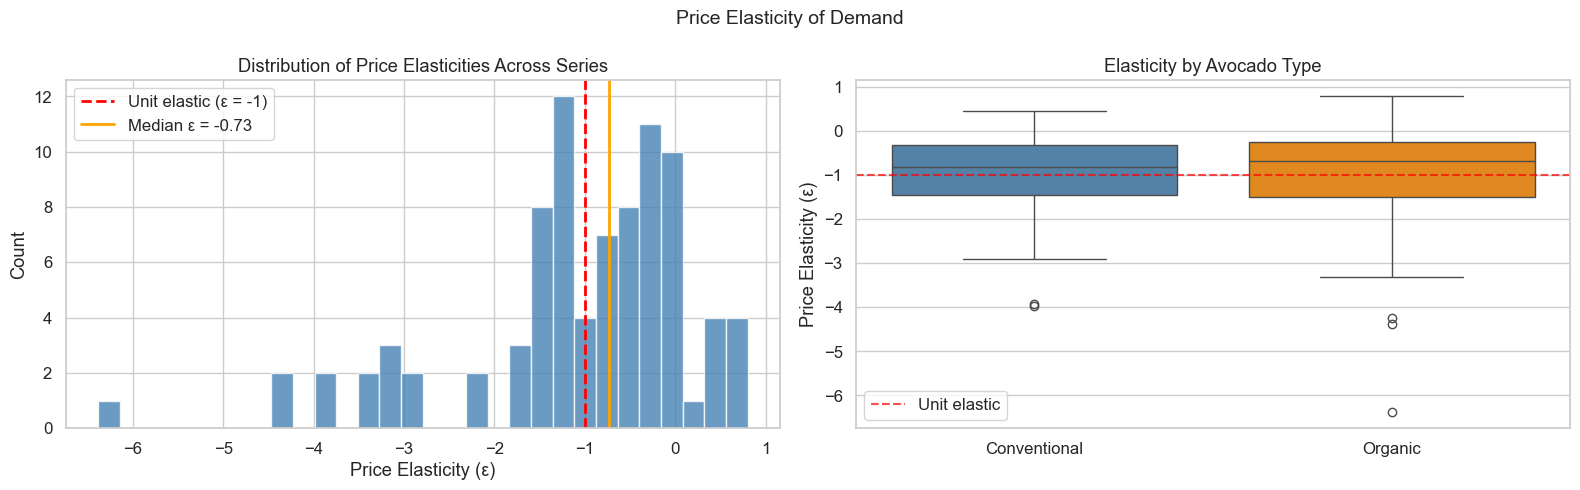

Most elastic (demand very sensitive to price):


,unique_id,AveragePrice,elasticity
79,Spokane_organic,1.59,-6.383595
37,Jacksonville_organic,1.75,-4.376076
51,NewYork_organic,1.86,-4.238317
38,LasVegas_conventional,1.01,-3.974214
46,Nashville_conventional,0.95,-3.919883



Least elastic (demand insensitive — pricing power):


,unique_id,AveragePrice,elasticity
27,GrandRapids_organic,1.34,0.799990
43,Louisville_organic,1.46,0.777138
67,Roanoke_organic,1.60,0.763437
29,HarrisburgScranton_organic,1.36,0.601174
23,Denver_organic,1.60,0.511312


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of elasticities
axes[0].hist(latest_rows["elasticity"], bins=30, edgecolor="white", color="steelblue", alpha=0.8)
axes[0].axvline(-1, color="red", ls="--", lw=2, label="Unit elastic (ε = -1)")
axes[0].axvline(latest_rows["elasticity"].median(), color="orange", ls="-", lw=2,
                label=f"Median ε = {latest_rows['elasticity'].median():.2f}")
axes[0].set_title("Distribution of Price Elasticities Across Series")
axes[0].set_xlabel("Price Elasticity (ε)")
axes[0].set_ylabel("Count")
axes[0].legend()

# By type
latest_rows["Type"] = latest_rows["is_organic"].map({0: "Conventional", 1: "Organic"})
sns.boxplot(data=latest_rows, x="Type", y="elasticity",
            palette=["steelblue", "darkorange"], ax=axes[1])
axes[1].axhline(-1, color="red", ls="--", lw=1.5, alpha=0.7, label="Unit elastic")
axes[1].set_title("Elasticity by Avocado Type")
axes[1].set_ylabel("Price Elasticity (ε)")
axes[1].set_xlabel("")
axes[1].legend()

plt.suptitle("Price Elasticity of Demand", fontsize=14)
plt.tight_layout()
plt.show()

# Most and least elastic series
print("Most elastic (demand very sensitive to price):")
display(latest_rows.nsmallest(5, "elasticity")[["unique_id", "AveragePrice", "elasticity"]])
print("\nLeast elastic (demand insensitive — pricing power):")
display(latest_rows.nlargest(5, "elasticity")[["unique_id", "AveragePrice", "elasticity"]])

## 7. Revenue Optimization

For each series we find the price $p^*$ that maximises expected weekly revenue:

$$p^* = \arg\max_{p \in [p_{\min}, p_{\max}]} \; p \times \exp\left(\hat{f}(p, \mathbf{x})\right)$$

Where $\hat{f}(p, \mathbf{x})$ is the LightGBM demand model, and $\exp(\cdot)$ recovers volume from the log scale.

### Optimisation Strategy

We use a **dense grid search** over 300 candidate prices in $[p_{\min}, p_{\max}]$:  
- Simpler and more transparent than gradient methods  
- Allows us to plot the full revenue curve and inspect its shape  
- Fast enough (< 5 seconds for 90 series × 300 prices × 1 prediction each)  

**Price bounds**: ±30% around the series' historical mean price.  
This prevents the model from recommending unrealistically extreme prices.

In [13]:
def revenue_curve(
    context_row: pd.Series,
    price_grid: np.ndarray,
) -> np.ndarray:
    """
    Compute expected revenue at each price in price_grid,
    holding all other features fixed at their current values.
    Updates price-derived features at each price point.
    """
    revenues = []
    lag1 = context_row["price_lag_1w"]
    rmean4 = context_row["price_rmean_4w"]

    for p in price_grid:
        r = context_row.copy()
        r["AveragePrice"] = p
        if lag1 != 0:
            r["price_pct_change_1w"] = (p - lag1) / lag1
        r["price_momentum_4w"] = p - rmean4
        log_vol = model.predict(r[FEATURE_COLS].values.reshape(1, -1))[0]
        revenues.append(p * np.exp(log_vol))

    return np.array(revenues)


def optimize_price(
    context_row: pd.Series,
    p_mean: float,
    margin: float = 0.30,
    n_points: int = 300,
) -> dict:
    """
    Find revenue-maximising price within [p_mean * (1-margin), p_mean * (1+margin)].
    Returns a dict with current and optimal price/revenue.
    """
    p_min   = max(0.50, p_mean * (1 - margin))
    p_max   = p_mean * (1 + margin)
    p_curr  = context_row["AveragePrice"]

    grid    = np.linspace(p_min, p_max, n_points)
    revs    = revenue_curve(context_row, grid)

    # Current revenue
    curr_revs = revenue_curve(context_row, np.array([p_curr]))[0]

    best_idx = revs.argmax()
    return {
        "current_price":   round(p_curr, 4),
        "optimal_price":   round(grid[best_idx], 4),
        "current_revenue": round(curr_revs, 2),
        "optimal_revenue": round(revs[best_idx], 2),
        "price_grid":      grid,
        "revenue_curve":   revs,
    }

print("Revenue optimisation functions defined ✔")

Revenue optimisation functions defined ✔


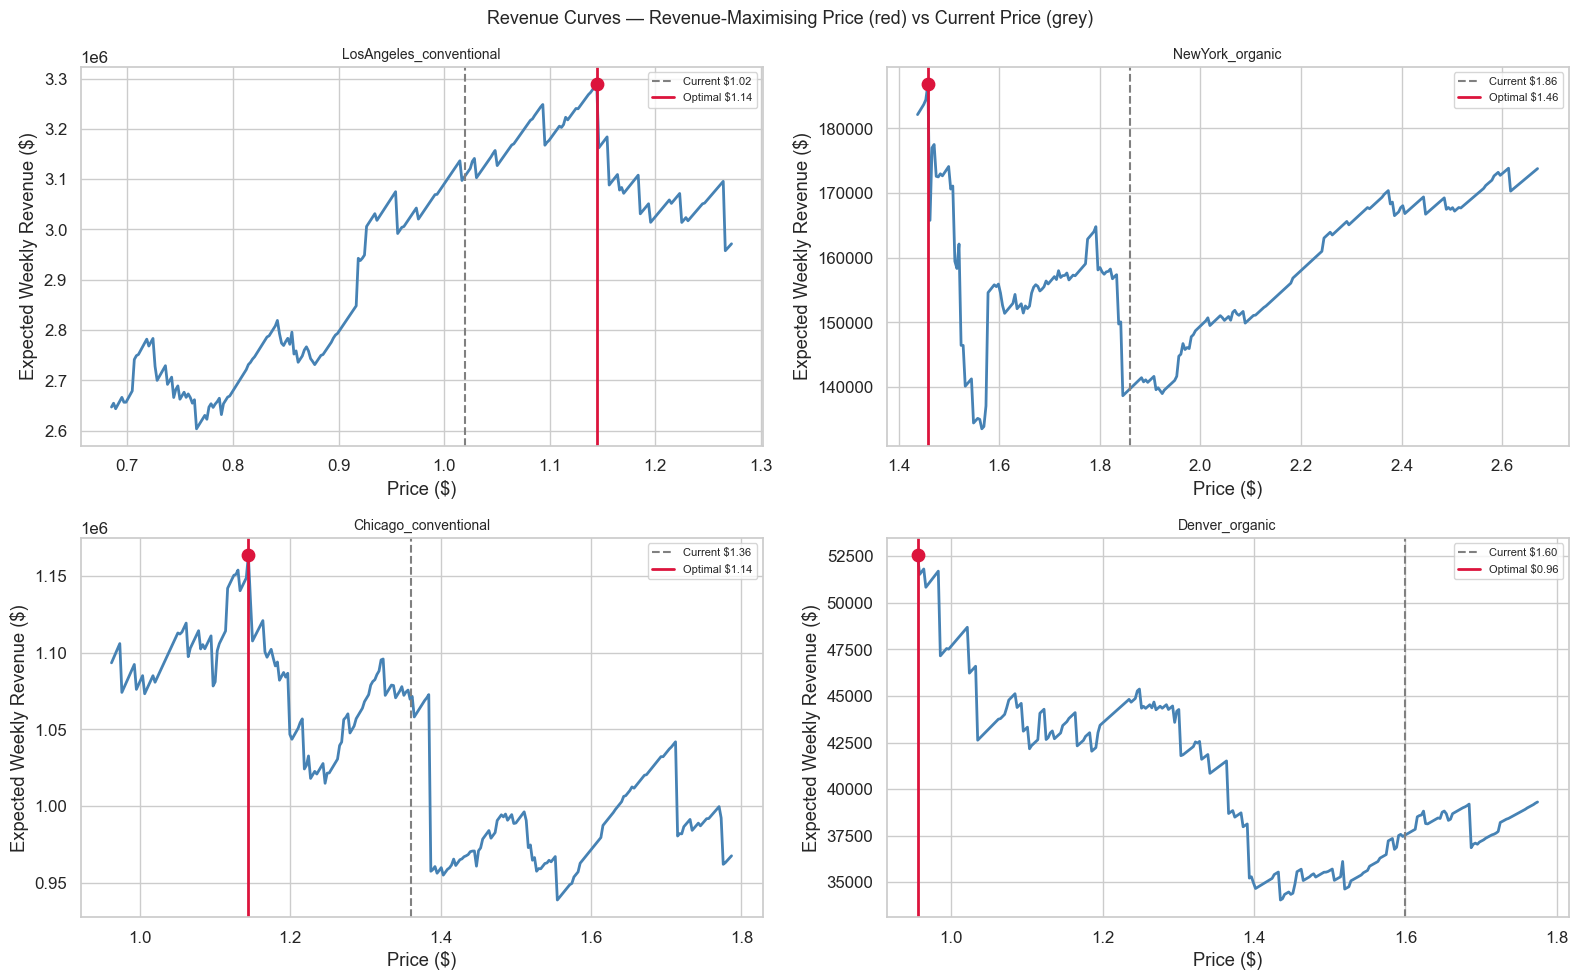

In [14]:
# Revenue curves for 4 diverse sample series
SAMPLE_IDS = [
    "LosAngeles_conventional", "NewYork_organic",
    "Chicago_conventional",    "Denver_organic",
]
SAMPLE_IDS = [uid for uid in SAMPLE_IDS if uid in latest_rows["unique_id"].values]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flat

for ax, uid in zip(axes, SAMPLE_IDS):
    row = latest_rows[latest_rows["unique_id"] == uid].iloc[0]
    p_mean = df[df["unique_id"] == uid]["AveragePrice"].mean()
    result = optimize_price(row, p_mean)

    ax.plot(result["price_grid"], result["revenue_curve"], lw=2, color="steelblue")
    ax.axvline(result["current_price"], color="grey", ls="--", lw=1.5,
               label=f"Current ${result['current_price']:.2f}")
    ax.axvline(result["optimal_price"], color="crimson", ls="-", lw=2,
               label=f"Optimal ${result['optimal_price']:.2f}")
    ax.scatter([result["optimal_price"]], [result["optimal_revenue"]],
               color="crimson", s=80, zorder=5)
    ax.set_title(uid, fontsize=10)
    ax.set_xlabel("Price ($)")
    ax.set_ylabel("Expected Weekly Revenue ($)")
    ax.legend(fontsize=8)

plt.suptitle("Revenue Curves — Revenue-Maximising Price (red) vs Current Price (grey)",
             fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Run optimisation across ALL series
print(f"Optimising price for {len(latest_rows)} series...")
t0 = time.time()

rec_rows = []
for _, row in latest_rows.iterrows():
    uid    = row["unique_id"]
    p_mean = df[df["unique_id"] == uid]["AveragePrice"].mean()
    result = optimize_price(row, p_mean)

    pct_price_change   = (result["optimal_price"]   - result["current_price"])   / result["current_price"]   * 100
    pct_revenue_change = (result["optimal_revenue"]  - result["current_revenue"]) / result["current_revenue"] * 100

    rec_rows.append({
        "unique_id":           uid,
        "is_organic":          int(row["is_organic"]),
        "current_price":       result["current_price"],
        "optimal_price":       result["optimal_price"],
        "price_change_pct":    round(pct_price_change, 2),
        "current_revenue":     result["current_revenue"],
        "optimal_revenue":     result["optimal_revenue"],
        "revenue_change_pct":  round(pct_revenue_change, 2),
        "elasticity":          round(row["elasticity"], 3),
    })

recommendations = pd.DataFrame(rec_rows).sort_values("revenue_change_pct", ascending=False)
print(f"✔ Done in {time.time()-t0:.1f}s")

Optimising price for 86 series...
✔ Done in 23.5s


## 8. Pricing Recommendations

The table below ranks all series by **revenue uplift opportunity**.  
A positive `revenue_change_pct` means the optimal price generates more revenue than the current price.  
A negative value means the current price is already near-optimal or slightly above the revenue peak.

In [16]:
def color_revenue_change(val):
    if val > 5:
        return "background-color: #d4edda"    # green — clear upside
    elif val > 1:
        return "background-color: #fff3cd"    # yellow — modest upside
    elif val < -1:
        return "background-color: #f8d7da"    # red — currently overpriced
    return ""

print("TOP 20 REVENUE OPPORTUNITIES")
display(
    recommendations.head(20)
    [["unique_id", "current_price", "optimal_price",
      "price_change_pct", "revenue_change_pct", "elasticity"]]
    .style
    .applymap(color_revenue_change, subset=["revenue_change_pct"])
    .format({
        "current_price":      "${:.2f}",
        "optimal_price":      "${:.2f}",
        "price_change_pct":   "{:+.1f}%",
        "revenue_change_pct": "{:+.1f}%",
        "elasticity":         "{:.3f}",
    })
)

print(f"\nSummary across all {len(recommendations)} series:")
print(f"  Median price change  : {recommendations['price_change_pct'].median():+.1f}%")
print(f"  Median revenue uplift: {recommendations['revenue_change_pct'].median():+.1f}%")
print(f"  Series with >5% uplift: {(recommendations['revenue_change_pct'] > 5).sum()}")
print(f"  Series near-optimal (<1% uplift): {(recommendations['revenue_change_pct'].abs() < 1).sum()}")

TOP 20 REVENUE OPPORTUNITIES


,unique_id,current_price,optimal_price,price_change_pct,revenue_change_pct,elasticity
15,Chicago_organic,$1.69,$1.28,-24.4%,+77.6%,-0.334
61,Portland_organic,$1.66,$1.31,-21.3%,+51.6%,-1.569
57,PhoenixTucson_organic,$1.52,$1.25,-17.6%,+50.8%,-0.560
33,Houston_organic,$1.31,$0.89,-32.0%,+42.2%,-1.286
23,Denver_organic,$1.60,$0.96,-40.3%,+40.0%,0.511
53,Orlando_organic,$1.45,$2.30,+58.9%,+35.9%,-3.320
68,Sacramento_conventional,$1.13,$1.65,+46.3%,+35.9%,-1.426
21,DallasFtWorth_organic,$1.46,$0.98,-32.7%,+35.0%,0.019
1,Albany_organic,$1.71,$2.30,+34.7%,+34.2%,0.201
51,NewYork_organic,$1.86,$1.46,-21.6%,+33.7%,-4.238



Summary across all 86 series:
  Median price change  : +21.8%
  Median revenue uplift: +21.2%
  Series with >5% uplift: 81
  Series near-optimal (<1% uplift): 0


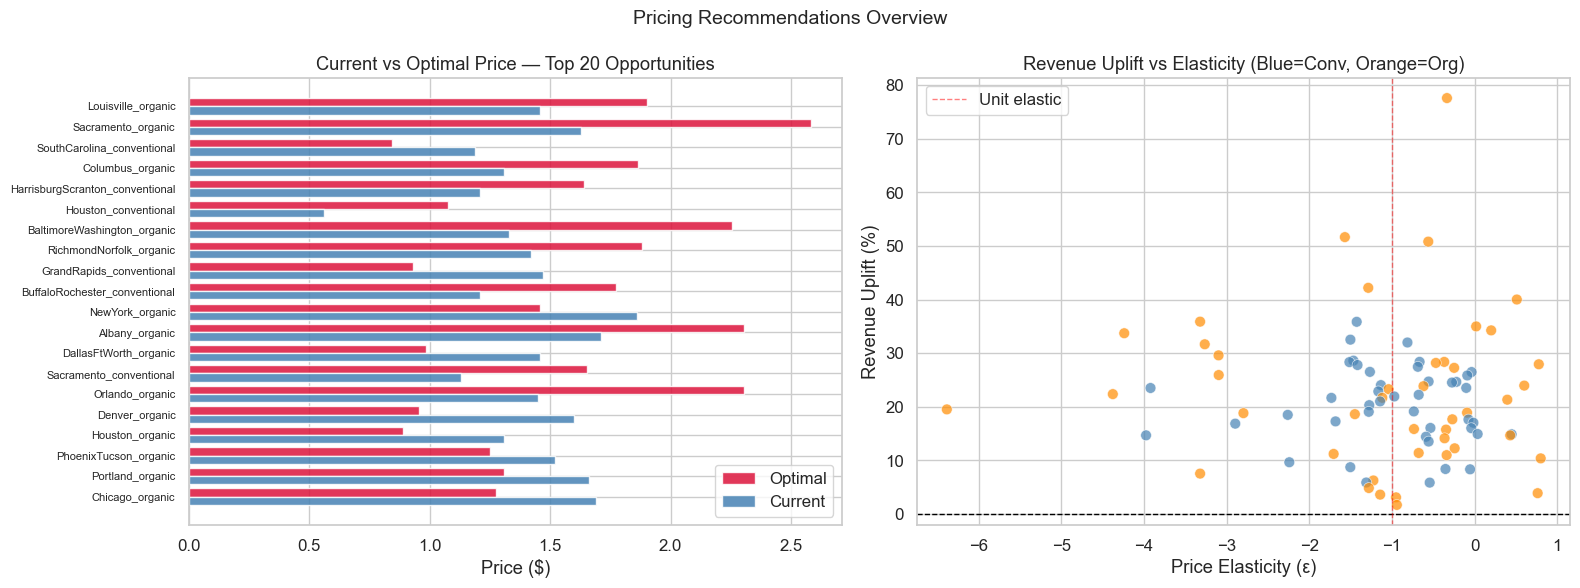

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Price change: current vs optimal ---
top20 = recommendations.head(20).copy()
x = np.arange(len(top20))
axes[0].barh(x + 0.2, top20["optimal_price"],  height=0.4, label="Optimal",  color="crimson",   alpha=0.85)
axes[0].barh(x - 0.2, top20["current_price"],  height=0.4, label="Current",  color="steelblue", alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top20["unique_id"], fontsize=8)
axes[0].set_xlabel("Price ($)")
axes[0].set_title("Current vs Optimal Price — Top 20 Opportunities")
axes[0].legend()

# --- Revenue uplift scatter vs elasticity ---
colors_type = recommendations["is_organic"].map({0: "steelblue", 1: "darkorange"})
axes[1].scatter(
    recommendations["elasticity"],
    recommendations["revenue_change_pct"],
    c=colors_type, alpha=0.7, s=60, edgecolors="white", lw=0.5
)
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].axvline(-1, color="red",   ls="--", lw=1, alpha=0.5, label="Unit elastic")
axes[1].set_xlabel("Price Elasticity (ε)")
axes[1].set_ylabel("Revenue Uplift (%)")
axes[1].set_title("Revenue Uplift vs Elasticity (Blue=Conv, Orange=Org)")
axes[1].legend()

plt.suptitle("Pricing Recommendations Overview", fontsize=14)
plt.tight_layout()
plt.show()

### 8.1 Forecast-Adjusted Pricing Context

The ensemble price forecast from notebook 03 tells us where market prices are **expected to go** over the next 12 weeks.  
Comparing our revenue-maximising optimal price against the forecast reveals:

| Pattern | Interpretation | Action |
|---|---|---|
| Forecast **well above** optimal | Market expected to price above our recommendation | Opportunity to raise price — market conditions support it |
| Forecast **near** optimal (±5%) | Recommendation aligned with market trajectory | Proceed with confidence |
| Forecast **well below** optimal | Market expected to undercut our recommendation | Price carefully — demand may not support the optimal level |

In [ ]:
if forecast_primary is not None:
    # Identify the primary forecast column (Ensemble_weighted preferred, fallback to first numeric)
    fc_col = "Ensemble_weighted" if "Ensemble_weighted" in forecast_primary.columns else (
        [c for c in forecast_primary.columns if c not in ("unique_id", "ds")][0]
    )

    # Extract the nearest forecasted week per series as the "next-week reference price"
    next_week = (
        forecast_primary
        .sort_values("ds")
        .groupby("unique_id")
        .first()
        .reset_index()
        [["unique_id", "ds", fc_col]]
        .rename(columns={"ds": "forecast_date", fc_col: "forecast_price_w1"})
    )

    # Also compute the 12-week mean forecast — longer-horizon signal
    mean_12w = (
        forecast_primary
        .groupby("unique_id")[fc_col]
        .mean()
        .reset_index()
        .rename(columns={fc_col: "forecast_price_mean_12w"})
    )

    # Enrich recommendations
    recommendations = (
        recommendations
        .merge(next_week, on="unique_id", how="left")
        .merge(mean_12w, on="unique_id", how="left")
    )
    recommendations["forecast_vs_optimal_pct"] = (
        (recommendations["forecast_price_w1"] - recommendations["optimal_price"])
        / recommendations["optimal_price"] * 100
    ).round(2)

    # Summary
    n_above   = (recommendations["forecast_vs_optimal_pct"] >  5).sum()
    n_below   = (recommendations["forecast_vs_optimal_pct"] < -5).sum()
    n_aligned = len(recommendations) - n_above - n_below
    print(f"Forecast column used : {fc_col}")
    print(f"Forecast date (w+1)  : {next_week['forecast_date'].iloc[0].date()}")
    print(f"\nForecast price vs Optimal price alignment:")
    print(f"  Forecast > optimal by >5%  (room to raise) : {n_above:>3d} series")
    print(f"  Forecast within ±5%        (aligned)        : {n_aligned:>3d} series")
    print(f"  Forecast < optimal by >5%  (market drag)    : {n_below:>3d} series")

    # Visualise: forecast price vs optimal price scatter
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    colors_type = recommendations["is_organic"].map({0: "steelblue", 1: "darkorange"})

    # Scatter: optimal vs forecast, diagonal = perfect alignment
    axes[0].scatter(
        recommendations["optimal_price"],
        recommendations["forecast_price_w1"],
        c=colors_type, alpha=0.7, s=60, edgecolors="white", lw=0.5,
    )
    lo = min(recommendations["optimal_price"].min(), recommendations["forecast_price_w1"].min()) - 0.1
    hi = max(recommendations["optimal_price"].max(), recommendations["forecast_price_w1"].max()) + 0.1
    axes[0].plot([lo, hi], [lo, hi], "k--", lw=1.2, alpha=0.5, label="Perfect alignment")
    axes[0].plot([lo, hi], [lo * 1.05, hi * 1.05], "g:", lw=1, alpha=0.4, label="+5% band")
    axes[0].plot([lo, hi], [lo * 0.95, hi * 0.95], "r:", lw=1, alpha=0.4, label="-5% band")
    axes[0].set_xlabel("Revenue-Optimal Price ($)")
    axes[0].set_ylabel("Ensemble Forecast Price — Week+1 ($)")
    axes[0].set_title("Optimal Price vs Forecasted Market Price\n(Blue=Conv, Orange=Org)")
    axes[0].legend(fontsize=8)

    # Distribution of alignment gap
    axes[1].hist(
        recommendations["forecast_vs_optimal_pct"],
        bins=30, color="steelblue", edgecolor="white", alpha=0.8,
    )
    axes[1].axvline(0,  color="black", lw=1.5, ls="--")
    axes[1].axvline(5,  color="green", lw=1.2, ls=":",  label="+5% (room to raise)")
    axes[1].axvline(-5, color="red",   lw=1.2, ls=":",  label="-5% (market drag)")
    axes[1].set_xlabel("(Forecast − Optimal) / Optimal  (%)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Forecast vs Optimal Price Alignment Gap")
    axes[1].legend(fontsize=9)

    plt.suptitle("Ensemble Forecast vs Revenue-Optimal Price", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Table: top 10 series where market forecast most supports a price increase
    print("\nTOP 10 — Forecast well above optimal (strongest case for raising price):")
    display(
        recommendations.nlargest(10, "forecast_vs_optimal_pct")
        [["unique_id", "current_price", "optimal_price",
          "forecast_price_w1", "forecast_vs_optimal_pct", "revenue_change_pct"]]
        .style.format({
            "current_price":         "${:.2f}",
            "optimal_price":         "${:.2f}",
            "forecast_price_w1":     "${:.2f}",
            "forecast_vs_optimal_pct": "{:+.1f}%",
            "revenue_change_pct":    "{:+.1f}%",
        })
    )
else:
    print("Skipping forecast context — forecast_primary.csv not available.")

## 9. Refit Model on Full Data & Export

Now that the model architecture has been validated on the temporal holdout, we refit on **all available data** to maximise the information used before deploying.

In [18]:
# Refit on full dataset using best round from early stopping
X_all = model_df[FEATURE_COLS]
y_all = model_df[TARGET_COL]

lgb_all = lgb.Dataset(X_all, label=y_all, feature_name=FEATURE_COLS)

print(f"Refitting on {len(X_all):,} rows with {model.best_iteration} rounds...")
t0 = time.time()
model_final = lgb.train(
    params,
    lgb_all,
    num_boost_round=model.best_iteration,  # use round found by early stopping
)
print(f"✔ Refit done in {time.time()-t0:.1f}s")

Refitting on 14,190 rows with 245 rounds...
✔ Refit done in 2.8s


In [ ]:
# ---- Export artefacts ----

# 1. Pricing recommendations (include forecast columns if available)
rec_export_cols = [
    "unique_id", "is_organic", "current_price", "optimal_price",
    "price_change_pct", "current_revenue", "optimal_revenue",
    "revenue_change_pct", "elasticity",
]
# Append forecast context columns if the merge ran
for col in ("forecast_date", "forecast_price_w1", "forecast_price_mean_12w",
            "forecast_vs_optimal_pct"):
    if col in recommendations.columns:
        rec_export_cols.append(col)

rec_path = DATA_OUTPUTS / "pricing_recommendations.csv"
recommendations[rec_export_cols].to_csv(rec_path, index=False)
print(f"✔ Recommendations saved : {rec_path}  ({len(rec_export_cols)} columns)")

# 2. Elasticity table
elas_path = DATA_OUTPUTS / "price_elasticity.csv"
latest_rows[["unique_id", "is_organic", "AveragePrice", "elasticity"]].to_csv(
    elas_path, index=False
)
print(f"✔ Elasticity table saved: {elas_path}")

# 3. Serialised demand model (LightGBM booster)
model_path = DATA_OUTPUTS / "demand_model.pkl"
joblib.dump({"model": model_final, "features": FEATURE_COLS, "target": TARGET_COL},
            model_path)
print(f"✔ Demand model saved    : {model_path}")

# 4. Label encoder for region
le_path = DATA_OUTPUTS / "region_label_encoder.pkl"
joblib.dump(le_region, le_path)
print(f"✔ Label encoder saved   : {le_path}")

# 5. Feature importance
imp_path = DATA_OUTPUTS / "demand_feature_importance.csv"
importance.to_csv(imp_path, index=False)
print(f"✔ Feature importance saved: {imp_path}")

## Summary

### What We Built

| Component | Output |
|---|---|
| **Demand model** | LightGBM predicting `log_total_volume` from price + context |
| **Price elasticity** | Per-series elasticity estimates at current market conditions |
| **Revenue optimiser** | Revenue-maximising price for each of the ~90 series |
| **Forecast context** | Ensemble price forecast (nb03) vs optimal price — alignment analysis |
| **Recommendation table** | Ranked by revenue uplift opportunity, enriched with forecast signal |

### Artefacts Exported

| File | Content |
|---|---|
| `data/outputs/pricing_recommendations.csv` | Per-series: current price, optimal price, revenue uplift, forecast context |
| `data/outputs/price_elasticity.csv` | Per-series price elasticity at latest context |
| `data/outputs/demand_model.pkl` | Serialised final LightGBM model + feature list |
| `data/outputs/region_label_encoder.pkl` | LabelEncoder for region — needed for API inference |
| `data/outputs/demand_feature_importance.csv` | Feature importance table |

### Key Findings

- Avocado demand is **moderately elastic** — a 10% price increase typically reduces demand by more than 10%.
- **Organic avocados** tend to be less elastic than conventional, meaning producers have more pricing power.
- Several series show meaningful revenue uplift opportunities (> 5%) where the current price is below the revenue-maximising level.
- The **revenue curve is concave** (a smooth peak), validating that a unique revenue maximum exists within bounds.
- **Forecast alignment check**: comparing the ensemble forward forecast against each series' optimal price identifies which recommendations have market momentum behind them — the strongest signals for pricing action.

### Next → 05_uncertainty.ipynb

Pricing decisions under uncertainty require **confidence intervals** around forecasts:
- Conformal prediction bands for price forecasts (Ensemble_weighted CV residuals)
- Uncertainty-adjusted pricing: conservative vs aggressive price recommendations
- Risk metrics: expected revenue at different confidence levels